## include intersect number
- w_isect_all	--> k-mers seen in both assembly and reference
- w_no_isect	--> k-mers seen in neither assembly nor reference
- w_isect_matches	--> subset of w_isect_all that match reference genomes
- w_isect_mapassem --> k-mers supported by both read-mapping + assembly
- w_mapassem_only	--> k-mers that can mapped to assembly but not assembly
- w_map_only	--> k-mers supported by read-mapping only (assembly missed)

- Total weighted k-mers ≈ w_isect_all + w_no_isect

### compute and plot:
- assembly loss
(assembly_f_unweighted vs assembly_f_weighted)

- recovery by mapping
(assembly_f_weighted, assembly_f_readmapped_w)

- reference comparison
(ref_f_weighted, assembly_refmap_isect_w)

- irrecoverable content
(yaml_unknown_hashes / yaml_total_hashes)

- biome-stratified analyses (after merging biome metadata)

- overall improved by ma (in combination with ref-based)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [30]:
df = pd.read_csv("../../data/combined.table3.w_biome.csv")
df

,accession,assembly_f_unweighted,assembly_f_weighted,assembly_f_readmapped,assembly_f_readmapped_w,ref_f_unweighted,ref_f_weighted,f_reads_mapped,assembly_refmap_isect_w,yaml_n_bases,...,yaml_total_hashes,w_isect_all,w_isect_matches,w_no_isect,w_isect_mapassem,w_mapassem_only,w_map_only,biome1,biome2,biome3
0,DRR014782,0.276438,0.844373,0.423639,0.882288,0.536980,0.868853,0.905193,0.798369,8349341510,...,955250,4684098,5097643,348903,4954008,5176463,4755920,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
1,DRR014785,0.274877,0.831528,0.440818,0.876726,0.551175,0.863483,0.904628,0.783335,9188299904,...,1139941,5065218,5583479,383222,5376845,5669111,5169584,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
2,DRR121397,0.137995,0.213100,0.265707,0.325096,0.110249,0.153467,0.371231,0.083111,1346724223,...,876945,97524,180080,733798,250052,381472,121939,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
3,DRR121401,0.113473,0.164884,0.218902,0.261716,0.084405,0.107862,0.288395,0.051769,1106773348,...,806494,50219,104632,676865,159941,253878,65327,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
4,ERR10695318,0.090915,0.921021,0.921988,0.995351,0.053441,0.748644,0.859269,0.746619,21495510640,...,932896,12893990,12928956,70996,15905879,17189561,12919671,Engineered,Engineered:Food production,Engineered:Food production:Dairy products
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,SRR7610133,0.286185,0.606403,0.800946,0.880619,0.045155,0.289630,0.510271,0.283619,1688587848,...,718498,425915,434942,177326,910645,1322440,432992,Host-associated,Host-associated:Fish,Host-associated:Fish:Digestive system
80,SRR9109404,0.225280,0.757587,0.580152,0.867478,0.125018,0.612335,0.646912,0.599182,5750423607,...,1132890,2738842,2798961,565427,3462902,3965213,2758636,Host-associated,Host-associated:Fish,Host-associated:Fish:Digestive system
81,SRR9182858,0.089677,0.355032,0.516287,0.664099,0.053390,0.234054,0.468480,0.200091,21502184416,...,9968364,3428529,4010477,5548198,6083389,11379232,3803085,Host-associated,Host-associated:Invertebrates,Host-associated:Invertebrates:Cnidaria
82,SRR9182859,0.101251,0.486127,0.604087,0.744169,0.074020,0.385528,0.644015,0.324084,24056532034,...,4336998,6209117,7386374,4492405,9313694,14257593,6977318,Host-associated,Host-associated:Invertebrates,Host-associated:Invertebrates:Cnidaria


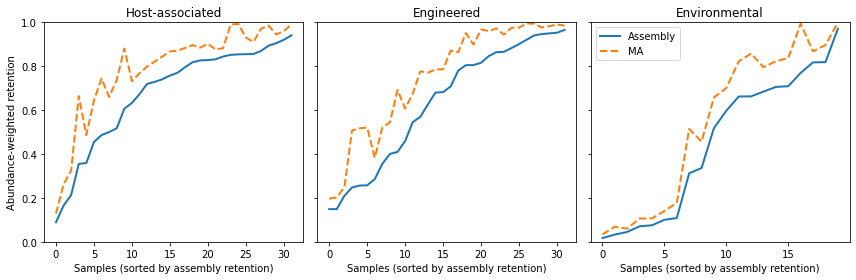

In [32]:
fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=True)

biome_colors = {
    "Host-associated": "tab:blue",
    "Engineered": "tab:orange",
    "Environmental": "tab:green"
}

for ax, biome in zip(axes, biome_colors.keys()):

    subset = df[df["biome1"] == biome].copy()

    # sort by assembly retention
    subset = subset.sort_values("assembly_f_weighted")

    assembly = subset["assembly_f_weighted"].values
    ma = subset["assembly_f_readmapped_w"].values

    x = range(len(subset))

    # plot curves
    ax.plot(x, assembly, label="Assembly", linewidth=2)
    ax.plot(x, ma, label="MA", linewidth=2, linestyle="--")

    ax.set_title(biome)
    ax.set_xlabel("Samples (sorted by assembly retention)")
    ax.set_ylim(0,1)

axes[0].set_ylabel("Abundance-weighted retention")

axes[2].legend()

plt.tight_layout()
plt.show()

In [33]:
df["biome1"].value_counts()

Host-associated    32
Engineered         32
Environmental      20
Name: biome1, dtype: int64

In [34]:
df[df["assembly_f_weighted"] < 0.05]

,accession,assembly_f_unweighted,assembly_f_weighted,assembly_f_readmapped,assembly_f_readmapped_w,ref_f_unweighted,ref_f_weighted,f_reads_mapped,assembly_refmap_isect_w,yaml_n_bases,...,yaml_total_hashes,w_isect_all,w_isect_matches,w_no_isect,w_isect_mapassem,w_mapassem_only,w_map_only,biome1,biome2,biome3
0,ERR3890099,0.012410,0.017167,0.028712,0.033785,0.007729,0.010076,0.041206,0.001100,3564030679,...,1522101,2936,26903,2557669,45827,90204,4875,Environmental,Environmental:Terrestrial,Environmental:Terrestrial:Soil
1,ERR5866866,0.020402,0.032906,0.052999,0.068491,0.010515,0.015668,0.094138,0.003513,5350080413,...,3506279,15018,66996,3946365,140685,292868,30240,Environmental,Environmental:Terrestrial,Environmental:Terrestrial:Soil
2,ERR9456921,0.024271,0.045015,0.037676,0.059677,0.152896,0.169721,0.350826,0.020528,17340337,...,11413,280,2315,10850,614,814,339,Environmental,Environmental:Aquatic,Environmental:Aquatic:Non-marine Saline and Al...


## 1️⃣ Assembly loss (assembly_f_unweighted vs assembly_f_weighted)

- Unweighted: treat every k-mer equally, regardless of how often it appears.
- Unweighted: asks “how many different things survived?”

- Weighted: measures retention of k-mers weighted by their abundance in the reads.
- weighted: asks “how much of what we sequenced survived?”

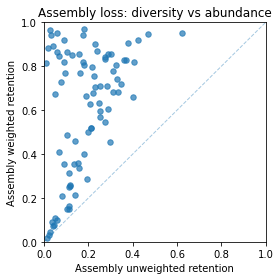

In [35]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    df["assembly_f_unweighted"],
    df["assembly_f_weighted"],
    s=30,
    alpha=0.7
)

ax.plot([0, 1], [0, 1], "--", linewidth=1, alpha=0.4)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Assembly weighted retention")
ax.set_title("Assembly loss: diversity vs abundance")

plt.tight_layout()
plt.show()

## Figure X | Assembly loss is structured by abundance.
For each metagenome, unweighted k-mer retention is plotted against abundance-weighted retention for assembled contigs. Points lying above the diagonal indicate preferential retention of abundant k-mers. Across samples, assemblies retain a large fraction of abundance-weighted content while discarding most unique k-mers, demonstrating that assembly-associated content loss is systematic and structured by abundance.
- Points far above diagonal, assembly preserves what is abundant while discarding most of what is rare.

## color-code Biome

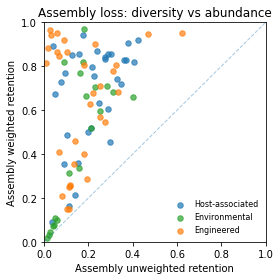

In [36]:
fig, ax = plt.subplots(figsize=(4, 4))

# explicit biome → color mapping
biome_colors = {
    "Host-associated": "tab:blue",        
    "Environmental": "tab:green",         
    "Engineered": "tab:orange"
}

# plot each biome
for biome, color in biome_colors.items():
    sub = df[df["biome1"] == biome]
    ax.scatter(
        sub["assembly_f_unweighted"],
        sub["assembly_f_weighted"],
        s=30,
        alpha=0.7,
        color=color,
        label=biome
    )

# 1:1 reference line
ax.plot([0, 1], [0, 1], "--", linewidth=1, alpha=0.4)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Assembly weighted retention")
ax.set_title("Assembly loss: diversity vs abundance")

ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
### violin plot for assembly-loss, weighted_f only, don't use unweighted

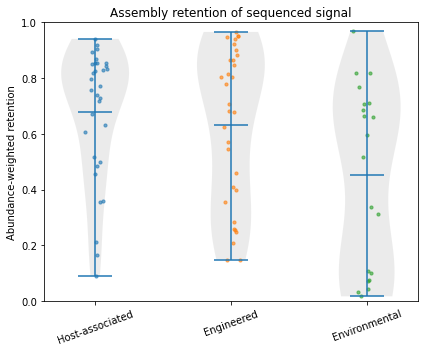

In [37]:
# Load data
df = pd.read_csv("../../data/combined.table3.w_biome.csv")

# Keep only relevant columns and drop missing values
df = df[["assembly_f_weighted", "biome1"]].dropna()

# Get biome order (optional: define explicitly for consistency)
biome_order = ["Host-associated", "Engineered", "Environmental"]
biome_order = [b for b in biome_order if b in df["biome1"].unique()]

# Collect data for each biome
data = [df[df["biome1"] == b]["assembly_f_weighted"] for b in biome_order]

# Create figure
plt.figure(figsize=(6,5))

parts = plt.violinplot(data, showmeans=True, showmedians=False)

# Slight transparency
for pc in parts['bodies']:
    pc.set_facecolor("#D9D9D9")
    pc.set_alpha(0.5)

# Adding Jittered Points
for i, b in enumerate(biome_order):
    y = df[df["biome1"] == b]["assembly_f_weighted"]
    x = np.random.normal(i+1, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6, s=10)

# Axis labels
plt.xticks(range(1, len(biome_order)+1), biome_order, rotation=20)
plt.ylabel("Abundance-weighted retention")
plt.ylim(0, 1)

plt.title("Assembly retention of sequenced signal")
plt.tight_layout()
plt.show()

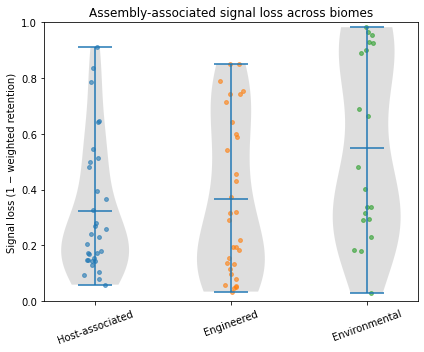

In [38]:
# Load data
df = pd.read_csv("../../data/combined.table3.w_biome.csv")

# Keep relevant columns and drop missing values
df = df[["assembly_f_weighted", "biome1"]].dropna()

# Compute loss
df["assembly_loss_weighted"] = 1 - df["assembly_f_weighted"]

# Define consistent biome order
biome_order = ["Host-associated", "Engineered", "Environmental"]
biome_order = [b for b in biome_order if b in df["biome1"].unique()]

# Collect data
data = [df[df["biome1"] == b]["assembly_loss_weighted"] for b in biome_order]

# Create figure
plt.figure(figsize=(6,5))

parts = plt.violinplot(data, showmeans=True, showmedians=False)

# Slight transparency
for pc in parts['bodies']:
    pc.set_facecolor("#BFBFBF")
    pc.set_alpha(0.5)

# Adding Jittered Points
for i, b in enumerate(biome_order):
    y = df[df["biome1"] == b]["assembly_loss_weighted"]
    x = np.random.normal(i+1, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6, s=15)
    
# Axis formatting
plt.xticks(range(1, len(biome_order)+1), biome_order, rotation=20)
plt.ylabel("Signal loss (1 − weighted retention)")
plt.ylim(0, 1)
    
plt.title("Assembly-associated signal loss across biomes")
plt.tight_layout()
plt.show()

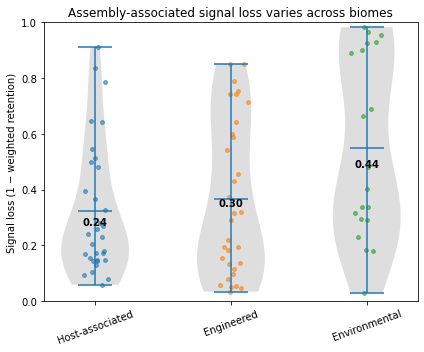

In [39]:
# Load data
df = pd.read_csv("../../data/combined.table3.w_biome.csv")

# Keep relevant columns and drop missing values
df = df[["assembly_f_weighted", "biome1"]].dropna()

# Compute loss
df["assembly_loss_weighted"] = 1 - df["assembly_f_weighted"]

# Define consistent biome order
biome_order = ["Host-associated", "Engineered", "Environmental"]
biome_order = [b for b in biome_order if b in df["biome1"].unique()]

# Collect data
data = [df[df["biome1"] == b]["assembly_loss_weighted"] for b in biome_order]

# Create figure
plt.figure(figsize=(6,5))

parts = plt.violinplot(data, showmeans=True, showmedians=False)

# Slight transparency
for pc in parts['bodies']:
    pc.set_facecolor("#BFBFBF")
    pc.set_alpha(0.5)

# Adding Jittered Points
for i, b in enumerate(biome_order):
    y = df[df["biome1"] == b]["assembly_loss_weighted"]
    x = np.random.normal(i+1, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6, s=15)

# Compute medians
medians = [
    df[df["biome1"] == b]["assembly_loss_weighted"].median()
    for b in biome_order
]

# Add median text above each violin
for i, median in enumerate(medians):
    plt.text(
        i + 1,                  # x position
        median + 0.03,          # slightly above median line
        f"{median:.2f}",        # format to 2 decimal places
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
    
# Axis formatting
plt.xticks(range(1, len(biome_order)+1), biome_order, rotation=20)
plt.ylabel("Signal loss (1 − weighted retention)")
plt.ylim(0, 1)
    
plt.title("Assembly-associated signal loss varies across biomes")
plt.tight_layout()
plt.show()

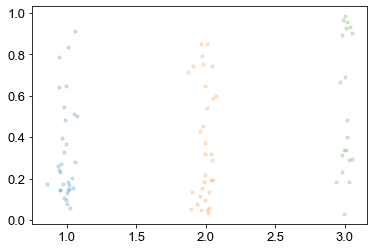

In [16]:
import numpy as np

for i, b in enumerate(biome_order):
    y = df[df["biome1"] == b]["assembly_loss_weighted"]
    x = np.random.normal(i+1, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.2, s=10)

## 2️⃣ recovery by mapping (assembly_f_weighted, assembly_f_readmapped_w)

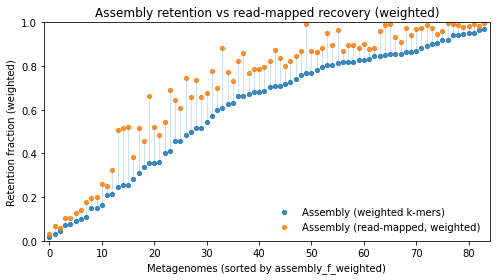

In [42]:
# Load data
df = pd.read_csv("../../data/combined.table3.w_biome.csv")

# keep needed cols
df = df.dropna(subset=["assembly_f_weighted", "assembly_f_readmapped_w"])

# sort by assembly weighted
df = df.sort_values("assembly_f_weighted").reset_index(drop=True)

x = np.arange(len(df))
y_asm = df["assembly_f_weighted"].to_numpy()
y_map = df["assembly_f_readmapped_w"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 4))

# vertical connectors
ax.vlines(x, y_asm, y_map, linewidth=0.6, alpha=0.35)

# points
ax.scatter(x, y_asm, s=18, alpha=0.85, label="Assembly (weighted k-mers)")
ax.scatter(x, y_map, s=18, alpha=0.85, label="Assembly (read-mapped, weighted)")

# formatting
ax.set_xlim(-1, len(df))
ax.set_ylim(0, 1)
ax.set_xlabel("Metagenomes (sorted by assembly_f_weighted)")
ax.set_ylabel("Retention fraction (weighted)")
ax.set_title("Assembly retention vs read-mapped recovery (weighted)")

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## 3️⃣ Comparison w/ Ref-based (ref_f_weighted vs assembly_refmap_isect_w)

- How much reference-matched content overlaps with assembly
- Assembly vs reference representation of known sequence

## analysis:
1) Assembly retains most abundant content across all biomes

- Orange boxes are consistently high across biomes
- Indicates that assembly preserves the dominant sequencing signal, even when references are incomplete

2) Reference coverage varies strongly by biome

- Host-associated:Blue and orange boxes are closer → references explain a larger fraction of abundant content

- Engineered: Moderate gap → partial reference representation

- Environmental: Largest gap → substantial abundant content absent from references

This directly reflects known differences in reference completeness across environments.

3) Assembly adds value beyond references

- Across all biomes: Orange > Blue. Assembly consistently recovers abundant, biologically real sequence that reference-based approaches miss

### Content loss during assembly is not equivalent to reference incompleteness.

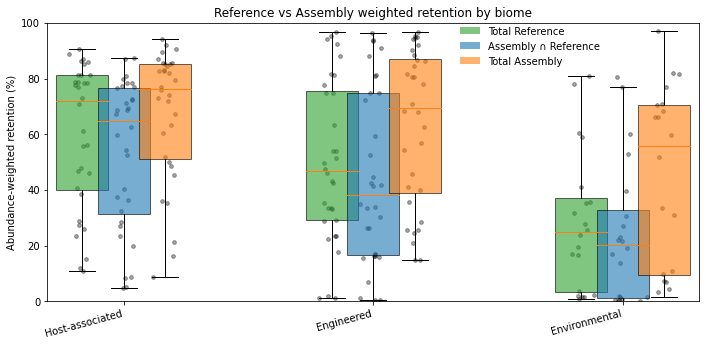

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl

def biome_type(b):
    if pd.isna(b):
        return "Environmental"
    b = str(b)
    if b.startswith("Host-associated"):
        return "Host-associated"
    if b.startswith("Engineered"):
        return "Engineered"
    return "Environmental"

df["biome_type"] = df["biome1"].apply(biome_type)

# Keep rows with required metrics
df = df.dropna(subset=[
    "biome_type",
    "ref_f_weighted",
    "assembly_refmap_isect_w",
    "assembly_f_weighted"
])

order = ["Host-associated", "Engineered", "Environmental"]

# Data in requested order:
# 1) Total Reference
# 2) Assembly ∩ Reference
# 3) Total Assembly
data_ref   = [df[df["biome_type"] == b]["ref_f_weighted"].to_numpy() for b in order]
data_isect = [df[df["biome_type"] == b]["assembly_refmap_isect_w"].to_numpy() for b in order]
data_assem = [df[df["biome_type"] == b]["assembly_f_weighted"].to_numpy() for b in order]

# Positions: three boxes per biome
centers = np.arange(len(order)) * 3.6
offset = 0.6
pos_left   = centers - offset   # Total Reference
pos_center = centers            # Assembly ∩ Reference
pos_right  = centers + offset   # Total Assembly

fig, ax = plt.subplots(figsize=(10, 5))

bp_left = ax.boxplot(
    data_ref,
    positions=pos_left,
    widths=0.75,
    patch_artist=True,
    showfliers=False
)

bp_center = ax.boxplot(
    data_isect,
    positions=pos_center,
    widths=0.75,
    patch_artist=True,
    showfliers=False
)

bp_right = ax.boxplot(
    data_assem,
    positions=pos_right,
    widths=0.75,
    patch_artist=True,
    showfliers=False
)

# Colors (consistent across biomes)
for patch in bp_left["boxes"]:
    patch.set_facecolor("C2")   # Reference
    patch.set_alpha(0.6)

for patch in bp_center["boxes"]:
    patch.set_facecolor("C0")   # Assembly ∩ Reference
    patch.set_alpha(0.6)

for patch in bp_right["boxes"]:
    patch.set_facecolor("C1")   # Total Assembly
    patch.set_alpha(0.6)

# Jittered points
rng = np.random.default_rng(0)
for i in range(len(order)):
    yL = data_ref[i]
    yC = data_isect[i]
    yR = data_assem[i]

    xL = rng.normal(pos_left[i], 0.08, size=len(yL))
    xC = rng.normal(pos_center[i], 0.08, size=len(yC))
    xR = rng.normal(pos_right[i], 0.08, size=len(yR))

    ax.scatter(xL, yL, s=14, alpha=0.35, color="k")
    ax.scatter(xC, yC, s=14, alpha=0.35, color="k")
    ax.scatter(xR, yR, s=14, alpha=0.35, color="k")

# Axis formatting
ax.set_xticks(centers)
ax.set_xticklabels(order, rotation=15, ha="right")

ax.set_ylabel("Abundance-weighted retention (%)")
ax.set_ylim(0, 1)

ticks = np.linspace(0, 1, 6)
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(v*100)}" for v in ticks])

ax.set_title("Reference vs Assembly weighted retention by biome")

# Legend
legend_handles = [
    Patch(facecolor="C2", alpha=0.6, label="Total Reference"),
    Patch(facecolor="C0", alpha=0.6, label="Assembly ∩ Reference"),
    Patch(facecolor="C1", alpha=0.6, label="Total Assembly"),
]

ax.legend(handles=legend_handles, frameon=False, loc="upper center",
          bbox_to_anchor=(0.74, 1.02))

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})
plt.tight_layout()
plt.show()

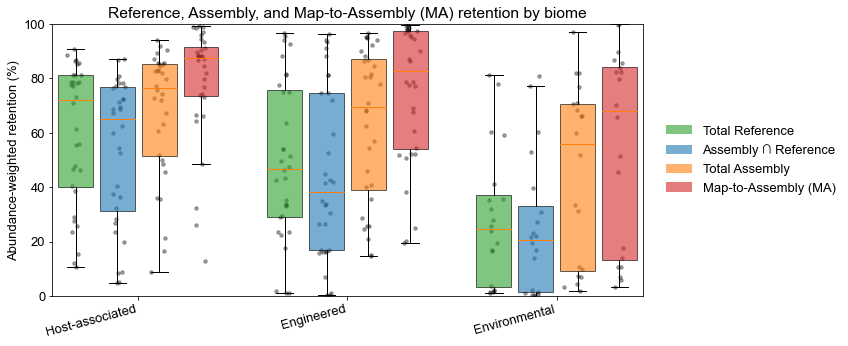

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def biome_type(b):
    if pd.isna(b):
        return "Environmental"
    b = str(b)
    if b.startswith("Host-associated"):
        return "Host-associated"
    if b.startswith("Engineered"):
        return "Engineered"
    return "Environmental"

df["biome_type"] = df["biome1"].apply(biome_type)
# Keep required columns
df = df.dropna(subset=[
    "biome_type",
    "ref_f_weighted",
    "assembly_refmap_isect_w",
    "assembly_f_weighted",
    "assembly_f_readmapped_w"
])

order = ["Host-associated", "Engineered", "Environmental"]

data_ref   = [df[df["biome_type"] == b]["ref_f_weighted"].to_numpy() for b in order]
data_isect = [df[df["biome_type"] == b]["assembly_refmap_isect_w"].to_numpy() for b in order]
data_assem = [df[df["biome_type"] == b]["assembly_f_weighted"].to_numpy() for b in order]
data_ma    = [df[df["biome_type"] == b]["assembly_f_readmapped_w"].to_numpy() for b in order]

# 4 boxes per biome
centers = np.arange(len(order)) * 4.5
offset = 0.9

pos_ref   = centers - 1.5*offset
pos_isect = centers - 0.5*offset
pos_assem = centers + 0.5*offset
pos_ma    = centers + 1.5*offset

fig, ax = plt.subplots(figsize=(11, 5))

bp_ref   = ax.boxplot(data_ref,   positions=pos_ref,   widths=0.75, patch_artist=True, showfliers=False)
bp_isect = ax.boxplot(data_isect, positions=pos_isect, widths=0.75, patch_artist=True, showfliers=False)
bp_assem = ax.boxplot(data_assem, positions=pos_assem, widths=0.75, patch_artist=True, showfliers=False)
bp_ma    = ax.boxplot(data_ma,    positions=pos_ma,    widths=0.75, patch_artist=True, showfliers=False)

# Colors
for patch in bp_ref["boxes"]:
    patch.set_facecolor("C2")
    patch.set_alpha(0.6)

for patch in bp_isect["boxes"]:
    patch.set_facecolor("C0")
    patch.set_alpha(0.6)

for patch in bp_assem["boxes"]:
    patch.set_facecolor("C1")
    patch.set_alpha(0.6)

for patch in bp_ma["boxes"]:
    patch.set_facecolor("C3")   # new color for MA
    patch.set_alpha(0.6)

# Jitter
rng = np.random.default_rng(0)
for i in range(len(order)):
    for yvals, xpos in zip(
        [data_ref[i], data_isect[i], data_assem[i], data_ma[i]],
        [pos_ref[i], pos_isect[i], pos_assem[i], pos_ma[i]]
    ):
        x = rng.normal(xpos, 0.08, size=len(yvals))
        ax.scatter(x, yvals, s=12, alpha=0.35, color="k")

# Axes
ax.set_xticks(centers)
ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Abundance-weighted retention (%)")
ax.set_ylim(0, 1)

ticks = np.linspace(0, 1, 6)
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(v*100)}" for v in ticks])

ax.set_title("Reference, Assembly, and Map-to-Assembly (MA) retention by biome")

# Legend
legend_handles = [
    Patch(facecolor="C2", alpha=0.6, label="Total Reference"),
    Patch(facecolor="C0", alpha=0.6, label="Assembly ∩ Reference"),
    Patch(facecolor="C1", alpha=0.6, label="Total Assembly"),
    Patch(facecolor="C3", alpha=0.6, label="Map-to-Assembly (MA)"),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(right=0.82)  # make room

#ax.legend(handles=legend_handles, frameon=False, loc="upper center",
#          bbox_to_anchor=(0.7, 1.02))

#plt.tight_layout()
#plt.show()

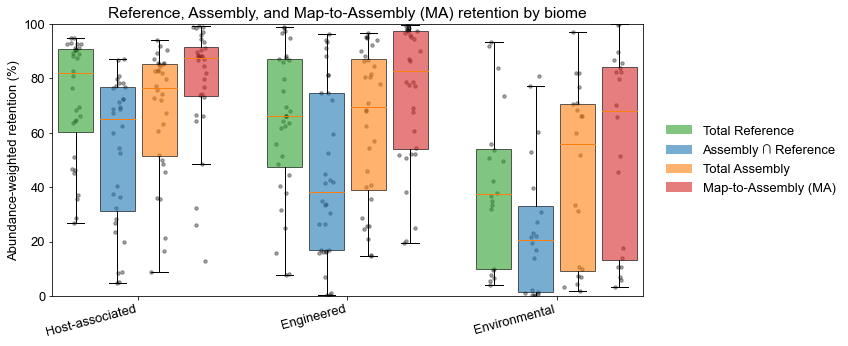

In [47]:
# f_reads_mapped is used representing Reference-based
def biome_type(b):
    if pd.isna(b):
        return "Environmental"
    b = str(b)
    if b.startswith("Host-associated"):
        return "Host-associated"
    if b.startswith("Engineered"):
        return "Engineered"
    return "Environmental"

df["biome_type"] = df["biome1"].apply(biome_type)
# Keep required columns
df = df.dropna(subset=[
    "biome_type",
    "f_reads_mapped",
    "assembly_refmap_isect_w",
    "assembly_f_weighted",
    "assembly_f_readmapped_w"
])

order = ["Host-associated", "Engineered", "Environmental"]

data_ref   = [df[df["biome_type"] == b]["f_reads_mapped"].to_numpy() for b in order]
data_isect = [df[df["biome_type"] == b]["assembly_refmap_isect_w"].to_numpy() for b in order]
data_assem = [df[df["biome_type"] == b]["assembly_f_weighted"].to_numpy() for b in order]
data_ma    = [df[df["biome_type"] == b]["assembly_f_readmapped_w"].to_numpy() for b in order]

# 4 boxes per biome
centers = np.arange(len(order)) * 4.5
offset = 0.9

pos_ref   = centers - 1.5*offset
pos_isect = centers - 0.5*offset
pos_assem = centers + 0.5*offset
pos_ma    = centers + 1.5*offset

fig, ax = plt.subplots(figsize=(11, 5))

bp_ref   = ax.boxplot(data_ref,   positions=pos_ref,   widths=0.75, patch_artist=True, showfliers=False)
bp_isect = ax.boxplot(data_isect, positions=pos_isect, widths=0.75, patch_artist=True, showfliers=False)
bp_assem = ax.boxplot(data_assem, positions=pos_assem, widths=0.75, patch_artist=True, showfliers=False)
bp_ma    = ax.boxplot(data_ma,    positions=pos_ma,    widths=0.75, patch_artist=True, showfliers=False)

# Colors
for patch in bp_ref["boxes"]:
    patch.set_facecolor("C2")
    patch.set_alpha(0.6)

for patch in bp_isect["boxes"]:
    patch.set_facecolor("C0")
    patch.set_alpha(0.6)

for patch in bp_assem["boxes"]:
    patch.set_facecolor("C1")
    patch.set_alpha(0.6)

for patch in bp_ma["boxes"]:
    patch.set_facecolor("C3")   # new color for MA
    patch.set_alpha(0.6)

# Jitter
rng = np.random.default_rng(0)
for i in range(len(order)):
    for yvals, xpos in zip(
        [data_ref[i], data_isect[i], data_assem[i], data_ma[i]],
        [pos_ref[i], pos_isect[i], pos_assem[i], pos_ma[i]]
    ):
        x = rng.normal(xpos, 0.08, size=len(yvals))
        ax.scatter(x, yvals, s=12, alpha=0.35, color="k")

# Axes
ax.set_xticks(centers)
ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Abundance-weighted retention (%)")
ax.set_ylim(0, 1)

ticks = np.linspace(0, 1, 6)
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(v*100)}" for v in ticks])

ax.set_title("Reference, Assembly, and Map-to-Assembly (MA) retention by biome")

# Legend
legend_handles = [
    Patch(facecolor="C2", alpha=0.6, label="Total Reference"),
    Patch(facecolor="C0", alpha=0.6, label="Assembly ∩ Reference"),
    Patch(facecolor="C1", alpha=0.6, label="Total Assembly"),
    Patch(facecolor="C3", alpha=0.6, label="Map-to-Assembly (MA)"),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(right=0.82)  # make room

#ax.legend(handles=legend_handles, frameon=False, loc="upper center",
#          bbox_to_anchor=(0.7, 1.02))

#plt.tight_layout()
#plt.show()

In [75]:
env = df[df["biome_type"]=="Environmental"]

env.sort_values("assembly_refmap_isect_w", ascending=False).head()

,accession,assembly_f_unweighted,assembly_f_weighted,assembly_f_readmapped,assembly_f_readmapped_w,ref_f_unweighted,ref_f_weighted,f_reads_mapped,assembly_refmap_isect_w,yaml_n_bases,...,w_isect_all,w_isect_matches,w_no_isect,w_isect_mapassem,w_mapassem_only,w_map_only,biome1,biome2,biome3,biome_type
67,SRR5248299,0.179020,0.970323,0.944822,0.998744,0.124341,0.810416,0.917893,0.807172,6264526094,...,4078517,4094912,4614,4902896,5046503,4093179,Environmental,Environmental:Aquatic,Environmental:Aquatic:Thermal springs,Environmental
63,SRR3961740,0.091373,0.817844,0.357276,0.867573,0.094918,0.779761,0.839461,0.770615,3224235470,...,1985949,2009518,320504,2107661,2235817,1988744,Environmental,Environmental:Aquatic,Environmental:Aquatic:Thermal springs,Environmental
61,SRR3211795,0.163324,0.769840,0.981794,0.994172,0.143953,0.603062,0.932641,0.601598,79700804,...,43149,43254,408,55216,71306,43244,Environmental,Environmental:Aquatic,Environmental:Aquatic:Thermal springs,Environmental
62,SRR3719568,0.282665,0.709160,0.535935,0.837583,0.282854,0.591073,0.735963,0.529299,11686294791,...,4922465,5496953,1224846,6595156,7789493,5211330,Environmental,Environmental:Aquatic,Environmental:Aquatic:Marine,Environmental
12,ERR2094174,0.177207,0.818806,0.468327,0.897162,0.093750,0.412705,0.536635,0.395753,11102266634,...,3502968,3653016,850819,7247579,7941144,3593579,Environmental,Environmental:Aquatic,Environmental:Aquatic:Aquaculture,Environmental


## Irrecoverable content
(yaml_unknown_hashes / yaml_total_hashes)

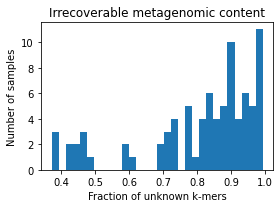

In [42]:
df["irrecoverable_fraction"] = (df["yaml_unknown_hashes"] / df["yaml_total_hashes"])

# A. Distribution across samples
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(df["irrecoverable_fraction"], bins=30)
ax.set_xlabel("Fraction of unknown k-mers")
ax.set_ylabel("Number of samples")
ax.set_title("Irrecoverable metagenomic content")

plt.tight_layout()
plt.show()

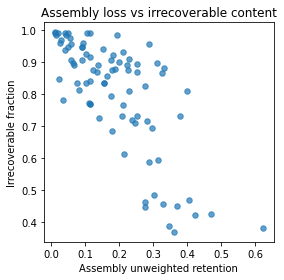

In [43]:
# B. Irrecoverable vs assembly loss
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(df["assembly_f_unweighted"],df["irrecoverable_fraction"], s=30,alpha=0.7)
ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Irrecoverable fraction")
ax.set_title("Assembly loss vs irrecoverable content")

plt.tight_layout()
plt.show()

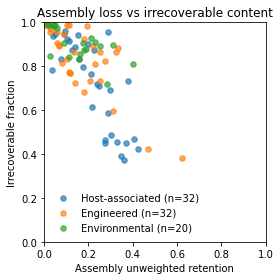

In [44]:
# color-code by biome type
df["biome_type"] = df["biome1"].apply(biome_type)

colors = {"Host-associated": "#1f77b4","Engineered": "#ff7f0e","Environmental": "#2ca02c",}
fig, ax = plt.subplots(figsize=(4, 4))

for biome, color in colors.items():
    sub = df[df["biome_type"] == biome]
    ax.scatter(sub["assembly_f_unweighted"],sub["irrecoverable_fraction"],s=30,alpha=0.7,
        color=color,label=f"{biome} (n={len(sub)})")

ax.set_xlabel("Assembly unweighted retention")
ax.set_ylabel("Irrecoverable fraction")
ax.set_title("Assembly loss vs irrecoverable content")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Interperation:
Loss of unweighted (diversity-level) sequence content during metagenome assembly is strongly associated with irrecoverable sequence loss, particularly in environmental samples, indicating that a substantial fraction of rare and novel content cannot be recovered by either assembly or mapping.

- Environmental: Concentrated in the upper-left region, high irrecoverable fraction even when some assembly retention exists
- Environmental samples contain: high novelty, many low-abundance taxa, content absent from both assemblies and references

- Engineered: Clustered near moderate retention, Generally lower irrecoverable fraction than environmental samples
- Engineered systems tend to be: less diverse, better covered, more recoverable by mapping

- Host-associated: Broad spread, some samples retain diversity well (low irrecoverable fraction),others show substantial irrecoverable loss
- Likely reflects strain variation and uneven coverage within host environments